<!-- # Proyecto Integrador
**Integrantes:** Sebastián Aucapiña, Bryan Montaguano -->

# Importar Librerías

In [2]:
# Sistema
import os
import warnings

# Data handling
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Kaggle API
from kaggle.api.kaggle_api_extended import KaggleApi

# Machine Learning - Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression

# Modelos - Clasificación
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Opcional: warnings off
warnings.filterwarnings("ignore")

In [3]:
# Establecemos una semilla única que será usada en todos los modelos

mi_semilla : int = 14

# Extracción de Datos

Según la documentacíon de [Kaggle](https://www.kaggle.com/docs/api#authentication), existen distintas herramientas para obtener la información a través de la api; en este caso utilizamos la herramienta oficial [Kagglehub](https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas) para obtener la información del dataset.

Dentro de Kaggle generamos una API Token la cual se ubica dentro de los secrets de los codespaces en el repositorio para la conexión con la API, evitando exponer el token de forma pública en el código.

In [ ]:
os.environ['KAGGLE_USERNAME'] = 'auca_srv'
os.environ['KAGGLE_KEY'] = os.environ['KAGGLE_API_TOKEN']

# Inicializar la API y autenticar
api = KaggleApi()
api.authenticate()

KeyError: 'KAGGLE_USERNAME'

In [6]:
# Dataset: zynicide/wine-reviews (solo ejemplo, reemplaza con el que necesites)
dataset_name = 'maharshipandya/-spotify-tracks-dataset'
download_path = './data'

# Descarga y descomprime automáticamente
api.dataset_download_files(dataset_name, path=download_path, unzip=True)

print("¡Dataset descargado en:", download_path, "!")

Dataset URL: https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
¡Dataset descargado en: ./data !


In [ ]:
# Transformar el CSV
df = pd.read_csv("./data/dataset.csv")

df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
# Imprimimos informacíon Básica sobre el Dataset Mediante
# las funciones .columns, .shape y los tipos de datos del Dataframe
print(f"Las variables dentro del dataset son:\n{df.columns}")
print("-" * 100)
print(f"El tamaño del dataset utilizado es (Filas / Columnas): {df.shape}")
print("-" * 100)
print("Variables obtenidas y sus tipos de datos:")
df.info()

Las variables dentro del dataset son:
Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')
----------------------------------------------------------------------------------------------------
El tamaño del dataset utilizado es (Filas / Columnas): (114000, 21)
----------------------------------------------------------------------------------------------------
Variables obtenidas y sus tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           11399

# Limpieza y Pre-Procesamiento

In [18]:
# Estadísticas descriptivas de las variables numéricas del dataset (danceability, energy, loudness, etc.)
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [19]:
# Ver cuántos nulos hay por columna
df_cleaned = df.isnull().sum()

df_cleaned[df_cleaned > 0]

artists       1
album_name    1
track_name    1
dtype: int64

In [20]:
# Eliminamos los nulos visualizados previamente
df_cleaned = df.dropna()

Verificamos que el dataset contiene pocos valores nulos en pocas columnas, por lo cual eliminar los 3 registros dentro del dataset no representará un cambio significativo para la ejecución y rendimiento del modelo.

In [21]:
# Verificamos si existen duplicados dentro del dataset con la funcíon duplicated
print(f"Cantidad de duplicados en el dataset:\n{df_cleaned.duplicated().sum()}")

Cantidad de duplicados en el dataset:
0


Se pudo visualizar mediante la función de *duplicated* que el dataset no contiene elementos duplicados; esto significa que en ninguna columna se visualizarán elementos duplicados que puedan afectar al modelo inicialmente.

# Visualización de Relaciones

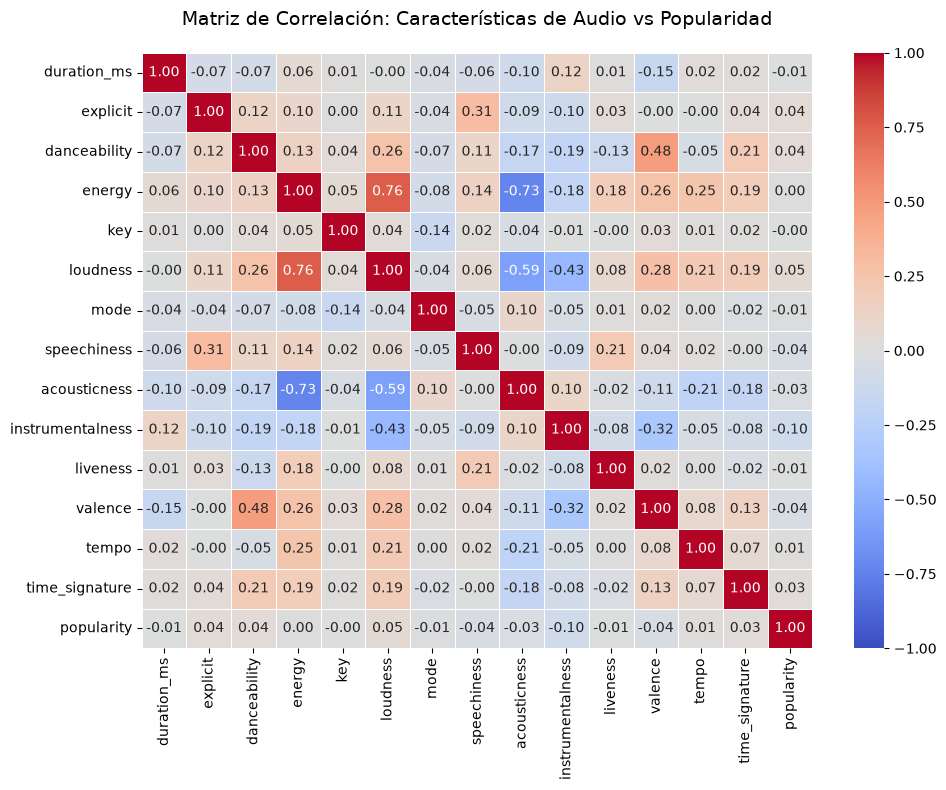

In [22]:
# 1. Matriz de Correlación
plt.figure(figsize=(10, 8))

# Esta es la lista de las features que deseamos comparar con la feature objetivo
features_list : list = [
    'duration_ms', 'explicit', 'danceability', 'energy',
    'key', 'loudness', 'mode', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 
    'tempo', 'time_signature'
]

# Calculamos la correlación de las features + el target
columnas_analisis = features_list + ['popularity']
matriz_corr = df_cleaned[columnas_analisis].corr()

# Creamos el mapa de calor
sns.heatmap(
    matriz_corr, 
    annot=True,          # Muestra los números dentro de cada celda
    cmap="coolwarm",     # Escala de colores (azul negativo, rojo positivo)
    fmt=".2f",           # Redondea a 2 decimales
    linewidths=0.5,      # Separa las celdas con una línea delgada
    vmin=-1, vmax=1      # Forzar los límites de la escala
)

plt.title("Matriz de Correlación: Características de Audio vs Popularidad", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [23]:
porcentaje_ceros = (df['popularity'] == 0).mean() * 100
print(f"{porcentaje_ceros:.2f}%")

14.05%


# 5. Hipótesis del Proyecto

---

## 5.1 Hipótesis Principal

> **H1:** Las dimensiones intrínsecas de las características matemáticas de audio (tales como `danceability`, `energy`, `loudness`, `valence`, entre otras) presentan una capacidad predictiva estadísticamente significativa sobre el índice de popularidad (`popularity`) de un track en Spotify, permitiendo modelar su comportamiento mediante algoritmos de regresión supervisada lineales y de ensamble.

En términos simples: **creemos que sí se puede predecir qué tan popular será una canción basándonos únicamente en sus propiedades sonoras**, sin necesidad de saber quién la canta ni en qué año salió.

Variable Objetivo ($Y$): 
- popularity (Métrica continua de 0 a 100).
- Variables de Entrada ($X$): Características acústicas y temporales extraídas del procesamiento de la señal de audio (excluyendo identificadores únicos de texto como `track_id`, `artists`, `album_name`, `track_name`).

# 6. Modelos Seleccionados

---

En esta sección definimos los tres modelos que vamos a aplicar sobre el dataset procesado.

## Tipo de problema

La variable objetivo `popularity` es un entero continuo entre 0 y 100, por lo que el problema es primariamente de **regresión**. No obstante, según las investigaciones realizadas en clase se logró identificar que los modelos de **clasificación** tuvieron un mejor resultado para clasificar una canción como popular/no pupular basados en un umbral específico. De esta manera, tomando en cuenta las justificaciones académicas, se desarrollarán los modelos usando estos dos enfoques para visualizar los resultados. 

---

## Modelo 1: Regresión Lineal Múltiple

**Tipo:** Regresión supervisada (Baseline)

**Justificación:** Es el punto de partida natural para cualquier problema de predicción numérica. Aunque asume linealidad matemática estricta entre las variables, nos sirve como **baseline** institucional para comparar el rendimiento de los modelos basados en árboles. Si un modelo sofisticado no supera a la regresión lineal, la complejidad matemática adicional no estaría justificada. Además, los coeficientes del modelo nos permiten interpretar de forma directa y transparente el impacto positivo o negativo de cada característica musical sobre la popularidad.

**Variables de entrada previstas:** `danceability`, `energy`, `key`, `loudness`, `mode`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`, `time_signature`, `duration_ms`, `explicit` (previamente estandarizadas mediante `StandardScaler`).

**Librería:** `sklearn.linear_model.LinearRegression`

---

## Modelo 2: Random Forest Regressor (Modelo Estrella)

**Tipo:** Ensemble supervisado basado en Bagging (Árboles de Decisión en Paralelo)

**Justificación:** Seleccionado como el **modelo estrella del proyecto** respaldado por la literatura científica analizada, la cual demuestra que los algoritmos basados en árboles obtienen el mejor desempeño en el análisis de audio de Spotify. Al construir múltiples árboles de decisión independientes en paralelo y promediar sus predicciones, reduce drásticamente el riesgo de sobreajuste (*overfitting*). Este modelo es ideal para nuestro dataset ya que maneja de forma nativa las relaciones no lineales complejas y la dispersión reflejada en la matriz de correlación inicial, permitiéndonos además extraer el *Feature Importance* para mapear qué variables determinan el éxito de un track.

**Variables de entrada previstas:** Las mismas características musicales que el Modelo 1.

**Librería:** `sklearn.ensemble.RandomForestRegressor`

---

## Modelo 3: Gradient Boosting (XGBoost)

**Tipo:** Ensemble supervisado basado en Boosting (Árboles de Decisión Secuenciales)

**Justificación:** Se incluye como un algoritmo de optimización avanzada para competir directamente contra nuestro modelo estrella. A diferencia de Random Forest, XGBoost construye los árboles de manera **secuencial**, donde cada nuevo árbol minimiza y corrige los errores de optimización del árbol anterior mediante el descenso de gradiente. Lo seleccionamos debido a su alta eficiencia computacional con grandes volúmenes de datos tabulares (Big Data) y su capacidad para detectar patrones ultra complejos no lineales en las señales acústicas que la regresión lineal o un bosque aleatorio básico podrían omitir.

**Variables de entrada previstas:** Las mismas características musicales que el Modelo 1, aplicando ajuste de hiperparámetros (`n_estimators`, `max_depth`, `learning_rate`).

**Librería:** `xgboost.XGBRegressor`

---

## Resumen comparativo de Arquitecturas

| Modelo | Tipo | Interpretabilidad | Capacidad No Lineal | Rol en el Proyecto |
|--------|------|-------------------|---------------------|--------------------|
| **Regresión Lineal Múltiple** | Regresión Lineal | Alta (Coeficientes directos) | Baja | Baseline Comparativo |
| **Random Forest Regressor** | Ensamble (Bagging) | Media (*Feature Importance*) | Alta | **Modelo Estrella (Científico)** |
| **XGBoost Regressor** | Ensamble (Boosting) | Baja (Caja Negra) | Muy Alta | Optimización y Máximo Rendimiento |

---


In [24]:
# ==========================================
# PREPROCESAMIENTO, ESCALADO Y MODELADO
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Supongamos que df_cleaned ya pasó por la eliminación de duplicados y nulos de la Entrega 1.
# Seleccionamos las columnas numéricas que representan las características musicales explicativas (X)
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
    'time_signature', 'duration_ms', 'explicit'
]

X = df_cleaned[caracteristicas_musicales]
y = df_cleaned['popularity']
semilla = 14

# 1. División de los datos en Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=semilla)

# 2. Escalado y Estandarización preliminar (Crucial para Regresión Lineal)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Set de entrenamiento: {X_train_scaled.shape}")
print(f"Set de prueba: {X_test_scaled.shape}")

# 3. Inicialización de los 3 Modelos Seleccionados
modelo_lr  = LinearRegression()
modelo_rf  = RandomForestRegressor(n_estimators=100, random_state=semilla, n_jobs=-1) # Optimizado con n_jobs=-1 para Colab
modelo_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=semilla, n_jobs=-1)

# 4. Entrenamiento de los modelos
print("\nEntrenando Regresión Lineal Múltiple...")
modelo_lr.fit(X_train_scaled, y_train)

print("Entrenando Random Forest Regressor (Modelo Estrella)...")
modelo_rf.fit(X_train_scaled, y_train)

print("Entrenando XGBoost Regressor...")
modelo_xgb.fit(X_train_scaled, y_train)

# 5. Generación de Predicciones
y_pred_lr  = modelo_lr.predict(X_test_scaled)
y_pred_rf  = modelo_rf.predict(X_test_scaled)
y_pred_xgb = modelo_xgb.predict(X_test_scaled)

# 6. Evaluación y Estructuración de Métricas
def calcular_metricas(nombre_modelo, y_real, y_pred):
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    mae  = mean_absolute_error(y_real, y_pred)
    r2   = r2_score(y_real, y_pred)
    return {
        'Modelo': nombre_modelo,
        'RMSE (Raíz Error Cuadrático)': round(rmse, 4),
        'MAE (Error Absoluto Medio)': round(mae, 4),
        'R² (Coef. Determinación)': round(r2, 4)
    }

resultados = [
    calcular_metricas('Regresión Lineal Múltiple', y_test, y_pred_lr),
    calcular_metricas('Random Forest (Estrella)', y_test, y_pred_rf),
    calcular_metricas('XGBoost Regressor', y_test, y_pred_xgb)
]

# Tabla Comparativa de Desempeño
df_resultados = pd.DataFrame(resultados).set_index('Modelo')
display(df_resultados)

Set de entrenamiento: (91199, 14)
Set de prueba: (22800, 14)

Entrenando Regresión Lineal Múltiple...
Entrenando Random Forest Regressor (Modelo Estrella)...
Entrenando XGBoost Regressor...


,RMSE (Raíz Error Cuadrático),MAE (Error Absoluto Medio),R² (Coef. Determinación)
Modelo,,,
Regresión Lineal Múltiple,21.8548,18.2080,0.0257
Random Forest (Estrella),14.9432,10.6058,0.5445
XGBoost Regressor,20.1170,16.3505,0.1745


In [25]:
# =====================================================================
# OBJETIVO 1: CLASIFICACIÓN BINARIA - ¿LOGRA LA CANCIÓN SALIR DEL CERO?
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 1. Definición expandida de características musicales explicativas
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 
    'time_signature', 'duration_ms', 'explicit'
]

# Forzar el tipo de dato correcto para variables categóricas/booleanas a numéricas
if 'explicit' in df_cleaned.columns and df_cleaned['explicit'].dtype == 'bool':
    df_cleaned['explicit'] = df_cleaned['explicit'].astype(int)

X = df_cleaned[caracteristicas_musicales]

# =========================================================================
# ASIGNACIÓN BINARIA:
# Clase 0 -> Popularidad = 0 ("Canción Muerta" / Sin repercusión inicial)
# Clase 1 -> Popularidad > 0 ("Logra salir" / Con tracción comercial)
# =========================================================================
y_binario = np.where(df_cleaned['popularity'] > 0, 1, 0)

# Fijamos la semilla solicitada
semilla_fase1 = 15

# 2. División estratificada (mantiene la proporción real de ceros en train y test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_binario, test_size=0.2, random_state=semilla_fase1, stratify=y_binario
)

# 3. Escalado y Estandarización de las variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("="*60)
print("INFORMACIÓN DE CONTROL DE DATOS (OBJETIVO 1)")
print("="*60)
print(f"Dimensiones del set de entrenamiento: {X_train_scaled.shape}")
print(f"Dimensiones del set de prueba: {X_test_scaled.shape}")
print(f"Distribución de clases en entrenamiento [Clase 0 , Clase 1]: {np.bincount(y_train)}")
print("-"*60)

# 4. Inicialización de los 3 Modelos de Clasificación (Con Semilla 15)
# Añadimos class_weight='balanced' para compensar estadísticamente el desbalance de los ceros
modelo_lr  = LogisticRegression(class_weight='balanced', random_state=semilla_fase1, max_iter=1000)
modelo_dt  = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=semilla_fase1) # Acotado a profundidad 4 para poder visualizarlo después
modelo_rf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=semilla_fase1, n_jobs=-1)

# 5. Entrenamiento de los Modelos
print("Entrenando Regresión Logística (Baseline)...")
modelo_lr.fit(X_train_scaled, y_train)

print("Entrenando Árbol de Decisión...")
modelo_dt.fit(X_train_scaled, y_train)

print("Entrenando Random Forest Classifier (Estrella)...")
modelo_rf.fit(X_train_scaled, y_train)

# 6. Generación de Predicciones sobre el Set de Prueba
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_dt = modelo_dt.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)

# 7. Construcción de Función para la Evaluación de Métricas Binarias
def evaluar_clasificador_binario(nombre_modelo, y_real, y_pred):
    return {
        'Modelo': nombre_modelo,
        'Exactitud (Accuracy)': round(accuracy_score(y_real, y_pred), 4),
        'Precisión (Precision)': round(precision_score(y_real, y_pred), 4),
        'Sensibilidad (Recall)': round(recall_score(y_real, y_pred), 4),
        'F1-Score': round(f1_score(y_real, y_pred), 4)
    }

res_fase1 = [
    evaluar_clasificador_binario('Regresión Logística', y_test, y_pred_lr),
    evaluar_clasificador_binario('Árbol de Decisión Simple', y_test, y_pred_dt),
    evaluar_clasificador_binario('Random Forest Classifier', y_test, y_pred_rf)
]

# Despliegue de la tabla comparativa de rendimiento
df_res_fase1 = pd.DataFrame(res_fase1).set_index('Modelo')
print("\n" + "="*60)
print("TABLA COMPARATIVA DE DESEMPEÑO - OBJETIVO 1")
print("="*60)
display(df_res_fase1)

INFORMACIÓN DE CONTROL DE DATOS (OBJETIVO 1)
Dimensiones del set de entrenamiento: (91199, 14)
Dimensiones del set de prueba: (22800, 14)
Distribución de clases en entrenamiento [Clase 0 , Clase 1]: [12815 78384]
------------------------------------------------------------
Entrenando Regresión Logística (Baseline)...
Entrenando Árbol de Decisión...
Entrenando Random Forest Classifier (Estrella)...

TABLA COMPARATIVA DE DESEMPEÑO - OBJETIVO 1


,Exactitud (Accuracy),Precisión (Precision),Sensibilidad (Recall),F1-Score
Modelo,,,,
Regresión Logística,0.5304,0.8990,0.5110,0.6516
Árbol de Decisión Simple,0.6001,0.9084,0.5947,0.7188
Random Forest Classifier,0.9401,0.9654,0.9649,0.9651


In [26]:
# =====================================================================
# OBJETIVO 2: HIT PREDICTION CONDICIONAL (TOP 20%)
# =====================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------------------------------
# 1. FILTRADO: solo canciones con interacción
# ---------------------------------------------------------------------
df_pop = df_cleaned[df_cleaned["popularity"] > 0].copy()

# ---------------------------------------------------------------------
# 2. DEFINICIÓN DEL TARGET (HIT = TOP 20%)
# ---------------------------------------------------------------------
threshold = df_pop["popularity"].quantile(0.80)

df_pop["hit"] = (df_pop["popularity"] >= threshold).astype(int)

# ---------------------------------------------------------------------
# 3. VARIABLES INDEPENDIENTES
# ---------------------------------------------------------------------
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'time_signature', 'duration_ms', 'explicit'
]

X = df_pop[caracteristicas_musicales]
y = df_pop["hit"].to_numpy()

# ---------------------------------------------------------------------
# 4. SPLIT
# ---------------------------------------------------------------------
semilla = 20

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=semilla, stratify=y
)

# ---------------------------------------------------------------------
# 5. ESCALADO
# ---------------------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------------------------------------------------
# 6. MODELOS
# ---------------------------------------------------------------------
modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=semilla)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=semilla, n_jobs=-1)
modelo_xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=semilla, n_jobs=-1)

# ---------------------------------------------------------------------
# 7. ENTRENAMIENTO
# ---------------------------------------------------------------------
modelo_dt.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)
modelo_xgb.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 8. PREDICCIONES
# ---------------------------------------------------------------------
pred_dt = modelo_dt.predict(X_test)
pred_rf = modelo_rf.predict(X_test)
pred_xgb = modelo_xgb.predict(X_test)

# ---------------------------------------------------------------------
# 9. MÉTRICAS
# ---------------------------------------------------------------------
def evaluar(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4)
    }

resultados = [
    evaluar("Decision Tree", y_test, pred_dt),
    evaluar("Random Forest", y_test, pred_rf),
    evaluar("XGBoost", y_test, pred_xgb)
]

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados

,Accuracy,Precision,Recall,F1
Modelo,,,,
Decision Tree,0.7908,0.5431,0.0153,0.0298
Random Forest,0.8861,0.9260,0.4965,0.6464
XGBoost,0.7958,0.7000,0.0460,0.0863


In [27]:
# =====================================================================
# OBJETIVO 2: HIT PREDICTION CONDICIONAL (TOP 20%)
# Solo canciones con interacción (popularity > 0)
# =====================================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ---------------------------------------------------------------------
# 1. Asegurar dataset limpio
# ---------------------------------------------------------------------
# Usa df_cleaned si existe, si no usa df
try:
    data = df_cleaned.copy()
except:
    data = df.copy()

# ---------------------------------------------------------------------
# 2. FILTRADO: solo canciones con interacción
# ---------------------------------------------------------------------
df_pop = data[data["popularity"] > 0].copy()

# ---------------------------------------------------------------------
# 3. DEFINICIÓN DEL TARGET: HIT = TOP 20%
# ---------------------------------------------------------------------
threshold = df_pop["popularity"].quantile(0.80)
df_pop["hit"] = (df_pop["popularity"] >= threshold).astype(int)

print("="*60)
print("OBJETIVO 2 - INFORMACIÓN DEL DATASET")
print("="*60)
print(f"Threshold (Top 20%): {threshold:.2f}")
print(f"Distribución de clases [No Hit, Hit]: {np.bincount(df_pop['hit'])}")

# ---------------------------------------------------------------------
# 4. FEATURES MUSICALES
# ---------------------------------------------------------------------
caracteristicas_musicales = [
    'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo',
    'time_signature', 'duration_ms', 'explicit'
]

# asegurar tipo correcto
if 'explicit' in df_pop.columns and df_pop['explicit'].dtype == 'bool':
    df_pop['explicit'] = df_pop['explicit'].astype(int)

X = df_pop[caracteristicas_musicales]
y = df_pop["hit"].values

# ---------------------------------------------------------------------
# 5. SPLIT
# ---------------------------------------------------------------------
semilla = 20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=semilla,
    stratify=y
)

# ---------------------------------------------------------------------
# 6. ESCALADO
# ---------------------------------------------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------------------------------------------------
# 7. MODELOS
# ---------------------------------------------------------------------
modelo_dt = DecisionTreeClassifier(max_depth=5, random_state=semilla)
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=semilla, n_jobs=-1)
modelo_xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=semilla,
    n_jobs=-1,
    eval_metric="logloss"
)

# ---------------------------------------------------------------------
# 8. ENTRENAMIENTO
# ---------------------------------------------------------------------
print("Entrenando modelos de HIT prediction...")

modelo_dt.fit(X_train, y_train)
modelo_rf.fit(X_train, y_train)
modelo_xgb.fit(X_train, y_train)

# ---------------------------------------------------------------------
# 9. PREDICCIONES
# ---------------------------------------------------------------------
pred_dt = modelo_dt.predict(X_test)
pred_rf = modelo_rf.predict(X_test)
pred_xgb = modelo_xgb.predict(X_test)

# ---------------------------------------------------------------------
# 10. EVALUACIÓN
# ---------------------------------------------------------------------
def evaluar(nombre, y_true, y_pred):
    return {
        "Modelo": nombre,
        "Accuracy": round(accuracy_score(y_true, y_pred), 4),
        "Precision": round(precision_score(y_true, y_pred), 4),
        "Recall": round(recall_score(y_true, y_pred), 4),
        "F1": round(f1_score(y_true, y_pred), 4)
    }

resultados = pd.DataFrame([
    evaluar("Decision Tree", y_test, pred_dt),
    evaluar("Random Forest", y_test, pred_rf),
    evaluar("XGBoost", y_test, pred_xgb)
]).set_index("Modelo")

print("\nRESULTADOS - OBJETIVO 2 (HIT PREDICTION)")
display(resultados)

OBJETIVO 2 - INFORMACIÓN DEL DATASET
Threshold (Top 20%): 56.00
Distribución de clases [No Hit, Hit]: [77435 20545]
Entrenando modelos de HIT prediction...

RESULTADOS - OBJETIVO 2 (HIT PREDICTION)


,Accuracy,Precision,Recall,F1
Modelo,,,,
Decision Tree,0.7908,0.5431,0.0153,0.0298
Random Forest,0.8861,0.9260,0.4965,0.6464
XGBoost,0.7958,0.7000,0.0460,0.0863


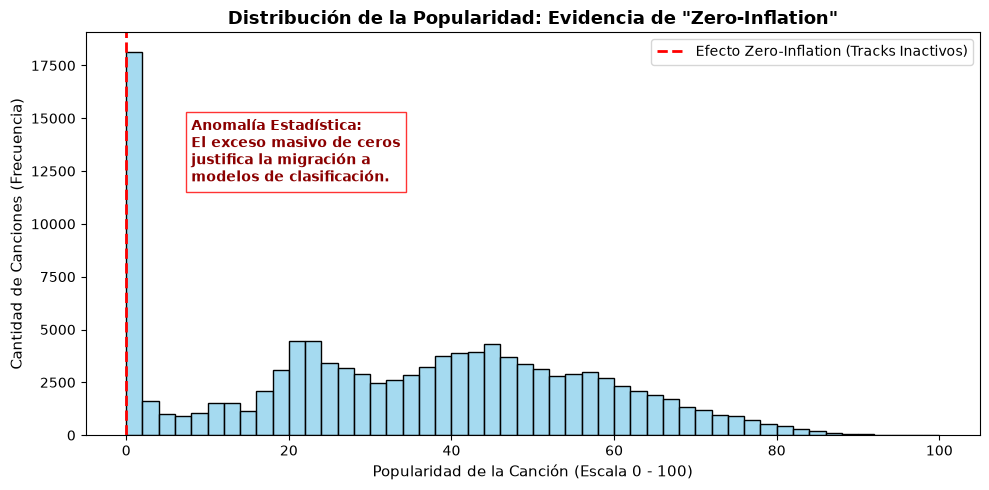

In [28]:
# =====================================================================
# VISUALIZACIÓN: HISTOGRAMA CON DIAGNÓSTICO DE ZERO-INFLATION
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

# Dibujamos el histograma general de la popularidad real
sns.histplot(df_cleaned['popularity'], bins=50, kde=False, color='skyblue', edgecolor='black')

# Resaltamos visualmente la barra del cero absoluto para la sustentación
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Efecto Zero-Inflation (Tracks Inactivos)')

plt.title('Distribución de la Popularidad: Evidencia de "Zero-Inflation"', fontsize=13, fontweight='bold')
plt.xlabel('Popularidad de la Canción (Escala 0 - 100)', fontsize=11)
plt.ylabel('Cantidad de Canciones (Frecuencia)', fontsize=11)

# Añadimos un cuadro de texto explicativo en el gráfico
plt.text(8, df_cleaned['popularity'].value_counts().max() * 0.75, 
         "Anomalía Estadística:\nEl exceso masivo de ceros\njustifica la migración a\nmodelos de clasificación.", 
         color='darkred', weight='bold', bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

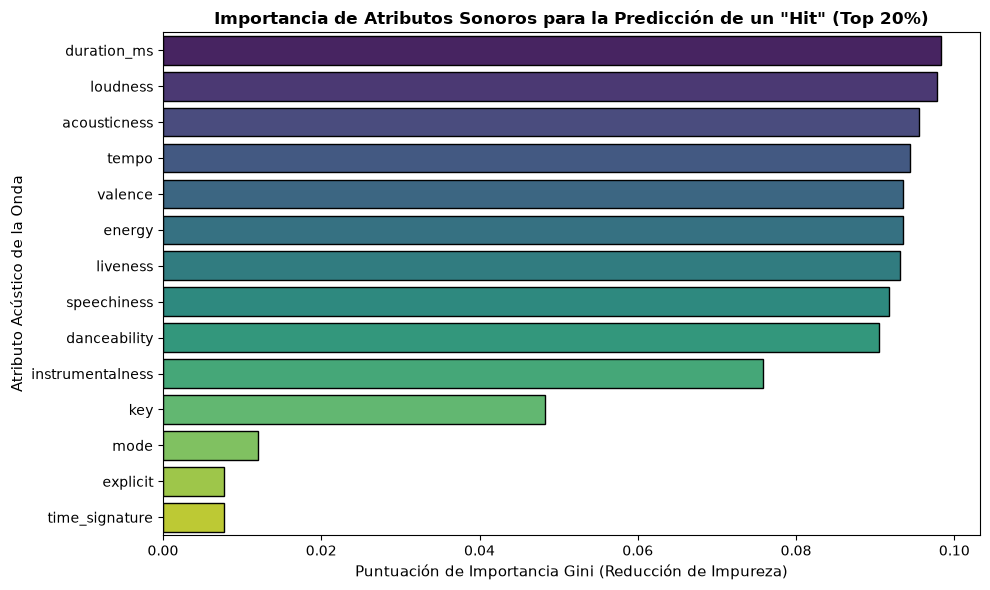

Ranking de importancia de variables físicas para entrar al Top 20%:


,Característica,Importancia
0,duration_ms,0.098325
1,loudness,0.097863
2,acousticness,0.095510
3,tempo,0.094408
4,valence,0.093507
5,energy,0.093474
6,liveness,0.093156
7,speechiness,0.091787
8,danceability,0.090431
9,instrumentalness,0.075844


In [29]:
# =====================================================================
# ANÁLISIS DE IMPORTANCIA DE VARIABLES (FEATURE IMPORTANCES) - ENFOQUE HIT (TOP 20%)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraemos las importancias del Random Forest entrenado para el Top 20%
importancias_hit = modelo_rf.feature_importances_

# 2. Estructuramos el DataFrame organizando los datos de mayor a menor importancia
df_importancia_hit = pd.DataFrame({
    'Característica': caracteristicas_musicales,
    'Importancia': importancias_hit
}).sort_values(by='Importancia', ascending=False)

# 3. Diseñamos la visualización gráfica con los parámetros modernos de Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importancia', 
    y='Característica', 
    data=df_importancia_hit, 
    hue='Característica',  # Evita el FutureWarning mapeando la variable en hue
    palette='viridis',     # Mantiene la estética profesional
    legend=False,          # Oculta la leyenda repetitiva ya que el eje Y contiene las etiquetas
    edgecolor='black'
)

plt.title('Importancia de Atributos Sonoros para la Predicción de un "Hit" (Top 20%)', fontsize=12, fontweight='bold')
plt.xlabel('Puntuación de Importancia Gini (Reducción de Impureza)', fontsize=11)
plt.ylabel('Atributo Acústico de la Onda', fontsize=11)
plt.tight_layout()
plt.show()

# 4. Imprimimos el desglose numérico exacto para su marco conceptual y diapositivas
print("Ranking de importancia de variables físicas para entrar al Top 20%:")
display(df_importancia_hit.reset_index(drop=True))

/tmp/ipykernel_1103/2134777001.py:94: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=9)


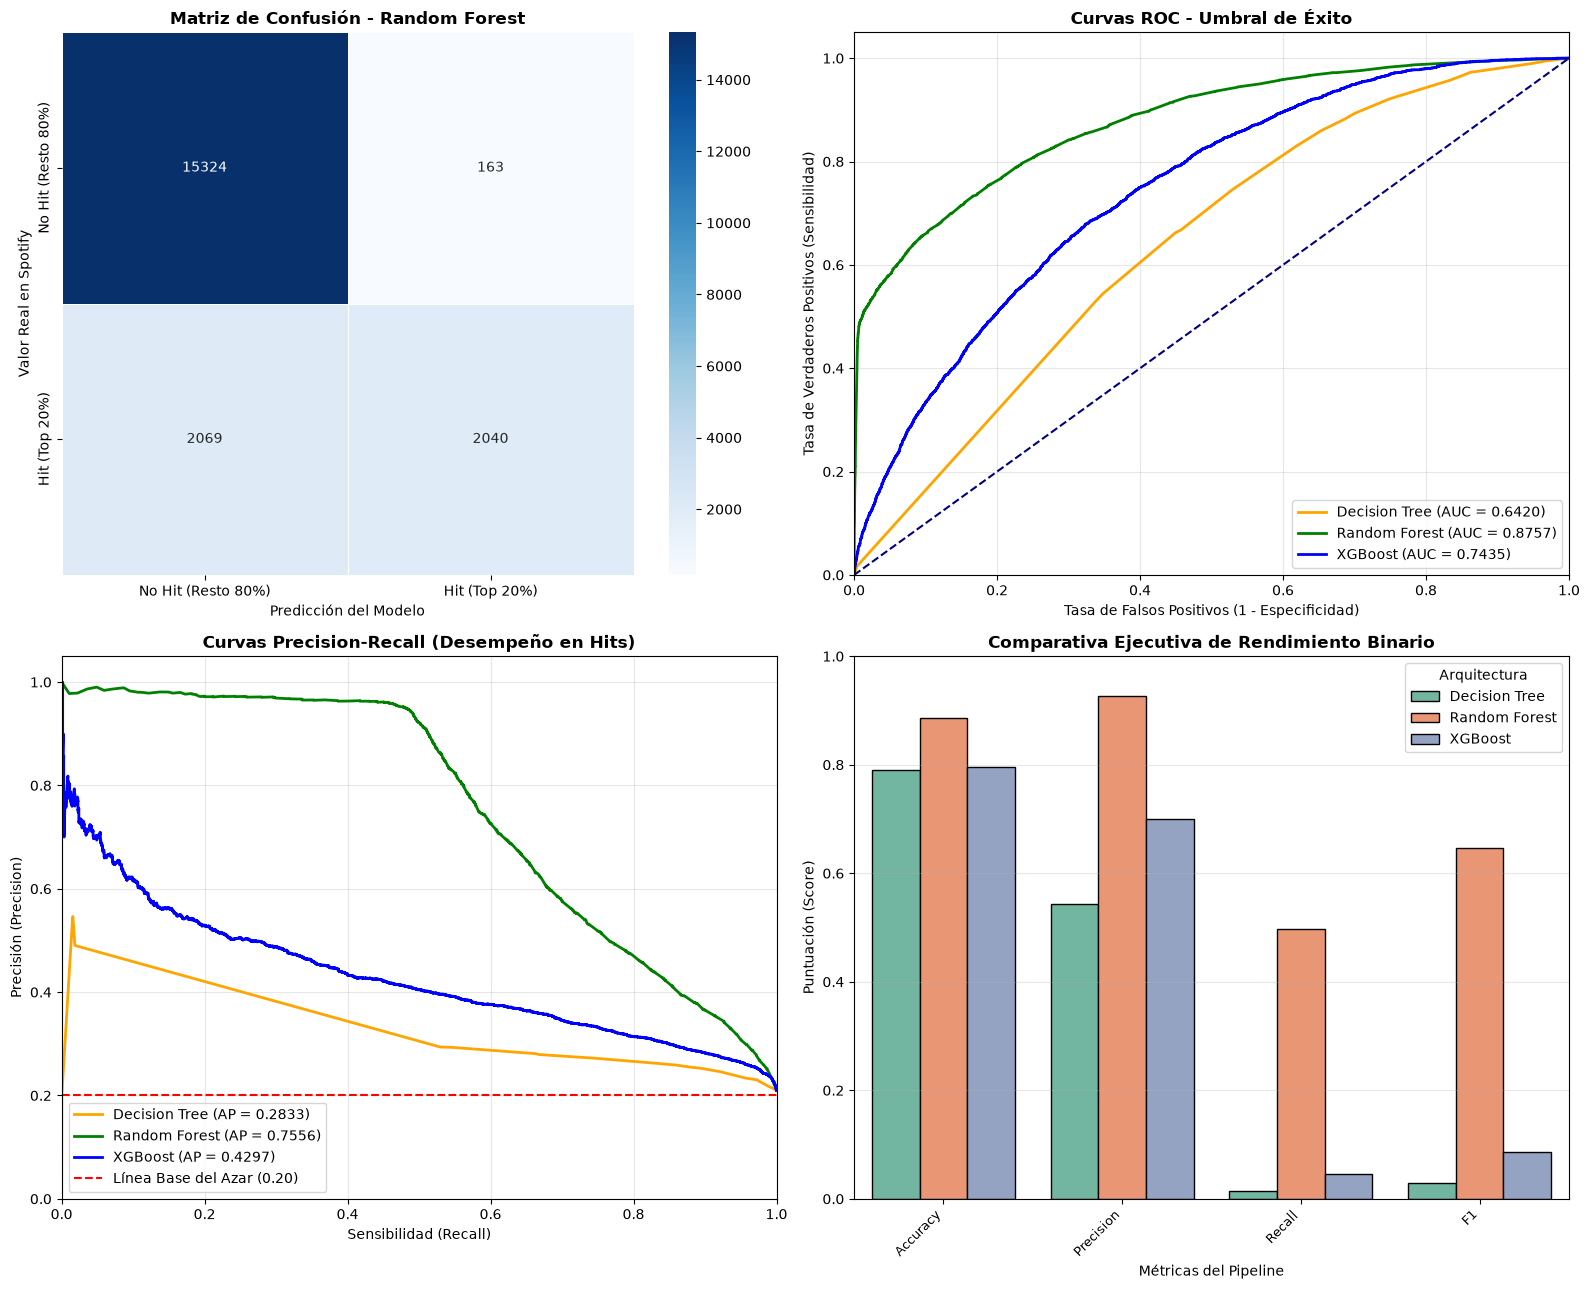

In [30]:
# =====================================================================
# SECCIÓN: EVALUACIÓN AVANZADA Y DIAGNÓSTICO DE MODELOS (HIT PREDICTION)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, 
    precision_recall_curve, average_precision_score
)

# Configurar el lienzo general para albergar las 4 gráficas en un panel 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# Nombres comerciales para las etiquetas binarias
labels_hit = ['No Hit (Resto 80%)', 'Hit (Top 20%)']

# -----------------------------------------------------------------
# GRÁFICO 1: Matriz de Confusión (Modelo Estrella: Random Forest)
# -----------------------------------------------------------------
cm = confusion_matrix(y_test, pred_rf)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
    xticklabels=labels_hit, yticklabels=labels_hit,
    edgecolor='gray', linewidths=0.5
)
axes[0, 0].set_title('Matriz de Confusión - Random Forest', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Predicción del Modelo', fontsize=10)
axes[0, 0].set_ylabel('Valor Real en Spotify', fontsize=10)

# -----------------------------------------------------------------
# GRÁFICO 2: Curvas ROC - AUC (Comparativa de los 3 Modelos)
# -----------------------------------------------------------------
# Extraemos las probabilidades de la clase positiva (1) para los modelos
prob_dt = modelo_dt.predict_proba(X_test)[:, 1]
prob_rf = modelo_rf.predict_proba(X_test)[:, 1]
prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

modelos_lista = [
    (prob_dt, 'Decision Tree', 'orange'),
    (prob_rf, 'Random Forest', 'green'),
    (prob_xgb, 'XGBoost', 'blue')
]

for prob, nombre, color in modelos_lista:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    axes[0, 1].plot(fpr, tpr, color=color, lw=2, label=f'{nombre} (AUC = {roc_auc:.4f})')

axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_title('Curvas ROC - Umbral de Éxito', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=10)
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=10)
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# -----------------------------------------------------------------
# GRÁFICO 3: Curvas Precision-Recall (Diagnóstico de Falsos Positivos)
# -----------------------------------------------------------------
for prob, nombre, color in modelos_lista:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    axes[1, 0].plot(recall, precision, color=color, lw=2, label=f'{nombre} (AP = {ap:.4f})')

# Línea base que representa la proporción real de Hits (20%)
axes[1, 0].axhline(y=0.20, color='red', linestyle='--', lw=1.5, label='Línea Base del Azar (0.20)')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_title('Curvas Precision-Recall (Desempeño en Hits)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Sensibilidad (Recall)', fontsize=10)
axes[1, 0].set_ylabel('Precisión (Precision)', fontsize=10)
axes[1, 0].legend(loc="lower left")
axes[1, 0].grid(True, alpha=0.3)

# -----------------------------------------------------------------
# GRÁFICO 4: Tabla de Métricas en Barras Agrupadas (Con Títulos Rotados)
# -----------------------------------------------------------------
# Convertimos el DataFrame 'resultados' que generó tu código a formato plano para Seaborn
df_plot = resultados.reset_index().melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

sns.barplot(
    x='Métrica', y='Valor', hue='Modelo', data=df_plot, 
    palette='Set2', edgecolor='black', ax=axes[1, 1]
)
axes[1, 1].set_title('Comparativa Ejecutiva de Rendimiento Binario', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Métricas del Pipeline', fontsize=10)
axes[1, 1].set_ylabel('Puntuación (Score)', fontsize=10)
axes[1, 1].set_ylim(0, 1.0)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].legend(title='Arquitectura')

# Aplicamos la rotación limpia a las etiquetas del eje X en este panel
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=9)

# Ajuste automático del layout para evitar colisiones de texto
plt.tight_layout()
plt.show()

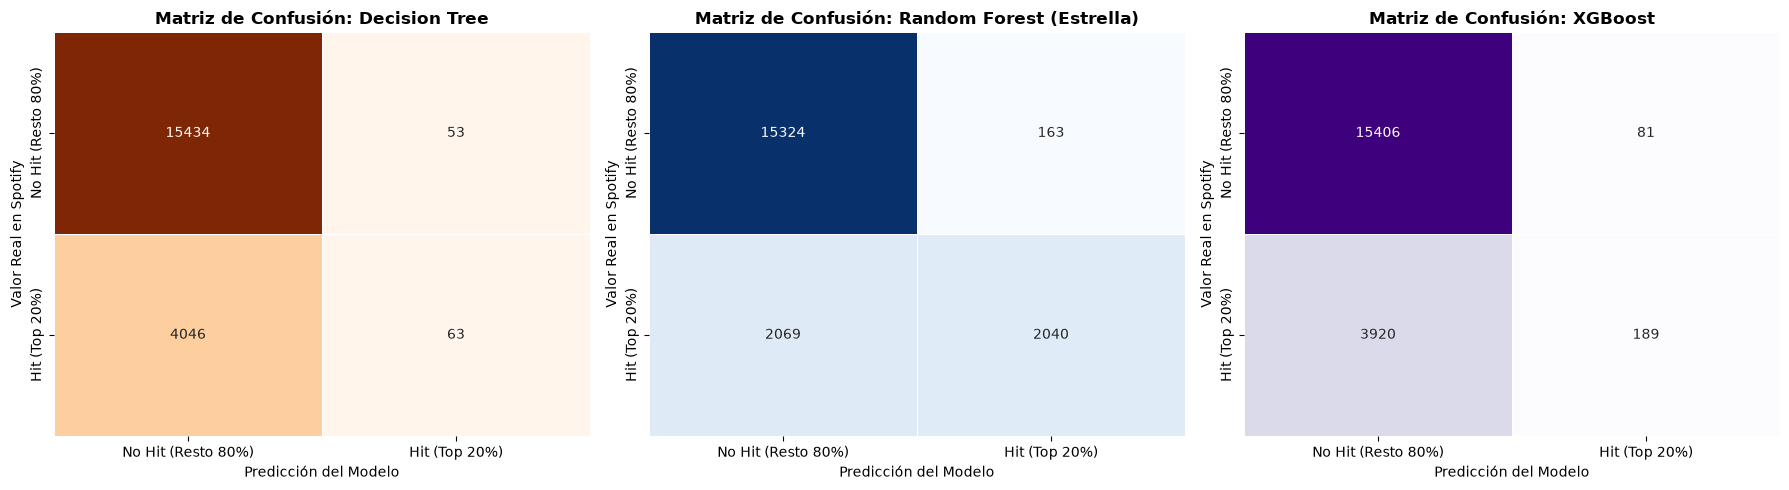

In [31]:
# =====================================================================
# SECCIÓN: COMPARATIVA DE MATRICES DE CONFUSIÓN (LOS 3 MODELOS)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Configurar un lienzo de 1 fila y 3 columnas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Lista de configuraciones de sus modelos binarios (Top 20%)
labels_hit = ['No Hit (Resto 80%)', 'Hit (Top 20%)']
matrices_config = [
    (y_test, pred_dt, 'Decision Tree', 'Oranges', axes[0]),
    (y_test, pred_rf, 'Random Forest (Estrella)', 'Blues', axes[1]),
    (y_test, pred_xgb, 'XGBoost', 'Purples', axes[2])
]

# Renderizar iterativamente cada matriz
for y_real, y_pred, nombre, mapa_color, ax in matrices_config:
    cm = confusion_matrix(y_real, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=mapa_color, ax=ax,
        xticklabels=labels_hit, yticklabels=labels_hit,
        edgecolor='gray', linewidths=0.5, cbar=False # Quitamos la barra lateral para limpieza visual
    )
    ax.set_title(f'Matriz de Confusión: {nombre}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo', fontsize=10)
    ax.set_ylabel('Valor Real en Spotify', fontsize=10)

plt.tight_layout()
plt.show()